# Introduction to quantum algorithms
This notebook serves as a basic introduction to quantum programming concepts and simulation.

## What is quantum simulator?
Quantum simulators such as PennyLane and Qiskit provide software environments for designing, running, and analyzing quantum circuits on classical computers. They simulate the behavior of qubits and gates, allowing users to prototype quantum algorithms without access to physical hardware.


**PennyLane** focuses on differentiable quantum programming and **hybrid quantum–classical machine learning**. It treats quantum circuits as differentiable computational graphs, enabling gradient-based optimization of variational circuits and quantum kernels. Circuits in PennyLane are created inside QNodes, which are Python functions decorated with @qml.qnode and filled with gate operations acting on specified wires.

[Pennylane](https://pennylane.ai/)

**Qiskit**, in contrast, is a general-purpose quantum computing framework emphasizing circuit construction, transpilation, and hardware execution on IBM quantum devices.

[Qistkit](https://www.ibm.com/quantum/qiskit)

## Setting up the environment

In [1]:
import os
import sys
import time
from pprint import pprint

In [2]:
# PennyLane and its NumPy wrapper
import pennylane as qml
import pennylane.numpy as np
from pennylane import math
from scipy.linalg import logm
import qiskit

# Qiskit for visualization
from qiskit.visualization import plot_bloch_vector

In [3]:
# Scientific stack
import numpy as onp
import matplotlib.pyplot as plt

In [4]:
# Utility: random seed for reproducibility
SEED = 42
np.random.seed(SEED)
onp.random.seed(SEED)

In [5]:
# Create a small helper to print installed versions (useful for reproducibility)
def print_versions():
    deps = {
        "python": sys.version.splitlines()[0],
        "pennylane": qml.__version__,
        "pennylane.numpy": qml.numpy.__name__ if hasattr(qml, 'numpy') else 'n/a',
        "numpy": onp.__version__,
        "matplotlib": plt.matplotlib.__version__,
    }
    pprint(deps)

In [6]:
# Print a short summary so the user sees the environment
print("PennyLane QML tutorial environment initialized.\n")
print_versions()

PennyLane QML tutorial environment initialized.

{'matplotlib': '3.9.4',
 'numpy': '2.4.6',
 'pennylane': '0.45.0',
 'pennylane.numpy': 'pennylane.numpy',
 'python': '3.11.15 (main, May 10 2026, 19:23:07) [Clang 22.1.3 ]'}


In [7]:
def bloch_from_state(state):
    """Return the Bloch vector (x,y,z) for a one-qubit state."""
    sigma_x = np.array([[0,1],[1,0]])
    sigma_y = np.array([[0,-1.0j],[1.0j,0]])
    sigma_z = np.array([[1,0],[0,-1]])

    rho = math.outer(state, math.conj(state))
    bx = math.real(math.trace(rho @ sigma_x))
    by = math.real(math.trace(rho @ sigma_y))
    bz = math.real(math.trace(rho @ sigma_z))
    return onp.array([bx, by, bz])


# --- Helper: run a PennyLane circuit and plot Bloch sphere ---

def plot_state_on_bloch(qnode_fn):
    state = qnode_fn()
    bloch_vec = bloch_from_state(state)

    print("State vector:", state)
    #print("Bloch vector:", bloch_vec)

    fig = plot_bloch_vector(bloch_vec, title="Bloch Sphere Representation")

    # force rendering in notebook
    display(fig)

    pass

## Single-Qubit States

In quantum computing, the basic unit of information is a **qubit**.

Unlike a classical bit (which is either 0 or 1), a qubit can exist in a **superposition** of both states:

$$|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$$

where:
- $\alpha, \beta$ are **complex numbers**
- $|\alpha|^2 + |\beta|^2 = 1$ (normalization condition)

### Dirac (bra-ket) notation
We represent quantum states using **ket notation**:
- $|0\rangle = \begin{bmatrix}1 \\ 0\end{bmatrix}$
- $|1\rangle = \begin{bmatrix}0 \\ 1\end{bmatrix}$

These form a basis for all single-qubit states.

In [8]:
# Create a quantum simulator.
# "default.qubit" is PennyLane's built-in state-vector simulator (more on different simulators later!).
# "wires=1" means that our quantum computer contains one qubit.
dev = qml.device("default.qubit", wires=1)

# A QNode is a quantum function that can be executed on a device.
# The @qml.qnode decorator converts the Python function below
# into a quantum circuit.
@qml.qnode(dev)
def circuit():
    # Circuit is a collective term for the set of quantum information processing instructions.
    # We will investigate circuits a little bit later.
    # No quantum gates are applied.
    # Therefore, the qubit remains in its default state |0⟩.
    
    # Return the complete quantum state vector.
    return qml.state()

# Execute the quantum circuit and display the result.
circuit()

array([1.+0.j, 0.+0.j])

The output is the quantum state vector:

$$[1, 0] \equiv |0\rangle$$

This means the system is entirely in the |0⟩ state.

We can now start manipulating this state using quantum gates.

In [9]:
@qml.qnode(dev)
def NOT_circuit():
    qml.X(wires=0)
    return qml.state()

NOT_circuit()

array([0.+0.j, 1.+0.j])

## The X Gate

The quantum analogue of the **NOT gate** is the **X gate**. In the vectorial notation it has the form of a matrix:

$$
X =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}.
$$

Just like the classical NOT gate flips a bit from 0 to 1 and from 1 to 0, the X gate swaps the computational basis states of a qubit:

$$
X|0\rangle = |1\rangle,
$$

$$
X|1\rangle = |0\rangle.
$$

Recall that the computational basis states are represented by the vectors

$$
|0\rangle =
\begin{pmatrix}
1 \\
0
\end{pmatrix},
\qquad
|1\rangle =
\begin{pmatrix}
0 \\
1
\end{pmatrix}.
$$

Applying the X gate to $|0\rangle$ gives

$$
X|0\rangle =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\begin{pmatrix}
1 \\
0
\end{pmatrix}
=
\begin{pmatrix}
0 \\
1
\end{pmatrix}
=
|1\rangle.
$$

Similarly,

$$
X|1\rangle =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\begin{pmatrix}
0 \\
1
\end{pmatrix}
=
\begin{pmatrix}
1 \\
0
\end{pmatrix}
=
|0\rangle.
$$

Therefore, when acting on the computational basis states, the X gate behaves exactly like a classical NOT gate.

## The Y and Z Gates

The existence and notation of the X gate suggests that there are also **Y** and **Z** gates. Together, the X, Y, and Z gates are known as the **Pauli gates** and play a fundamental role in quantum computing.

They are defined by the following matrices:

$$
X =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix},
\qquad
Y =
\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix},
\qquad
Z =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}.
$$

Unlike the X gate, whose action is easy to understand from a classical perspective, the effects of the Y and Z gates are less intuitive. 

In [10]:
# Y|0>
@qml.qnode(dev)
def y_on_zero():
    qml.Y(wires=0)
    return qml.state()

# Y|1>
@qml.qnode(dev)
def y_on_one():
    qml.X(wires=0)  # Prepare |1>
    qml.Y(wires=0)
    return qml.state()

# Z|0>
@qml.qnode(dev)
def z_on_zero():
    qml.Z(wires=0)
    return qml.state()

# Z|1>
@qml.qnode(dev)
def z_on_one():
    qml.X(wires=0)  # Prepare |1>
    qml.Z(wires=0)
    return qml.state()

print("Y|0> =", y_on_zero())
print("Y|1> =", y_on_one())
print("Z|0> =", z_on_zero())
print("Z|1> =", z_on_one())

Y|0> = [0.+0.j 0.+1.j]
Y|1> = [0.-1.j 0.+0.j]
Z|0> = [ 1.+0.j -0.+0.j]
Z|1> = [ 0.+0.j -1.+0.j]


To gain some intuition, let us apply them to the default qubit state

$$
|0\rangle =
\begin{pmatrix}
1 \\
0
\end{pmatrix}.
$$

Applying the Y gate gives

$$
Y|0\rangle =
\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix}
\begin{pmatrix}
1 \\
0
\end{pmatrix}
=
\begin{pmatrix}
0 \\
i
\end{pmatrix}
=
i|1\rangle.
$$

Applying the Z gate gives

$$
Z|0\rangle =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
\begin{pmatrix}
1 \\
0
\end{pmatrix}
=
\begin{pmatrix}
1 \\
0
\end{pmatrix}
=
|0\rangle.
$$

We observe that:

- The **Y gate** transforms $|0\rangle$ into $i|1\rangle$. Apart from the complex factor $i$, this is similar to the action of the X gate.
- The **Z gate** leaves $|0\rangle$ unchanged.

At this point, the action of the Z gate may seem uninteresting. However, its effect becomes apparent when the qubit is in a superposition state. We will revisit the Z gate after introducing superposition and the Hadamard gate.

## The Hadamard Gate

So far, we have only seen gates that map computational basis states to other computational basis states (possibly up to a phase). The **Hadamard gate** is the first gate that truly introduces *quantum superposition*.

It is defined by the matrix:

$$
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}.
$$

Unlike the Pauli gates, the Hadamard gate does not simply flip or phase-flip a qubit. Instead, it creates **superposition states**.

Let us see its action on the computational basis.

### Action on $|0\rangle$

$$
H|0\rangle =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
\begin{pmatrix}
1 \\
0
\end{pmatrix}
=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
1
\end{pmatrix}
=
\frac{|0\rangle + |1\rangle}{\sqrt{2}}.
$$

### Action on $|1\rangle$

$$
H|1\rangle =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
\begin{pmatrix}
0 \\
1
\end{pmatrix}
=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
-1
\end{pmatrix}
=
\frac{|0\rangle - |1\rangle}{\sqrt{2}}.
$$

### Interpretation

The Hadamard gate transforms a definite classical-like state into a balanced quantum superposition:

- $|0\rangle \rightarrow \frac{|0\rangle + |1\rangle}{\sqrt{2}}$
- $|1\rangle \rightarrow \frac{|0\rangle - |1\rangle}{\sqrt{2}}$

This means that after applying the Hadamard gate, the qubit is no longer in a definite classical state. Instead, it encodes **both possibilities at the same time in its amplitudes**.

This is one of the key ingredients that makes quantum computation fundamentally different from classical computation.

Let us now see this in PennyLane.

In [11]:
# --- Hadamard on |0> ---
@qml.qnode(dev)
def h_on_zero():
    qml.Hadamard(wires=0)
    return qml.state()

# --- Hadamard on |1> ---
@qml.qnode(dev)
def h_on_one():
    qml.X(wires=0)        # prepare |1>
    qml.Hadamard(wires=0)
    return qml.state()

# --- Z on H|0> ---
@qml.qnode(dev)
def z_on_h_zero():
    qml.Hadamard(wires=0)
    qml.Z(wires=0)
    return qml.state()

# --- Z on H|1> ---
@qml.qnode(dev)
def z_on_h_one():
    qml.X(wires=0)        # prepare |1>
    qml.Hadamard(wires=0)
    qml.Z(wires=0)
    return qml.state()

print(f"Remember: 1/sqrt(2): {1/np.sqrt(2):.8f}")
print("---------------------")
print("H|0>   =", h_on_zero())
print("H|1>   =", h_on_one())
print("Z H|0> =", z_on_h_zero())
print("Z H|1> =", z_on_h_one())

Remember: 1/sqrt(2): 0.70710678
---------------------
H|0>   = [0.70710678+0.j 0.70710678+0.j]
H|1>   = [ 0.70710678+0.j -0.70710678+0.j]
Z H|0> = [ 0.70710678+0.j -0.70710678+0.j]
Z H|1> = [0.70710678+0.j 0.70710678-0.j]


## The $|+\rangle$ and $|-\rangle$ States

It is useful to introduce two commonly used quantum states that arise naturally from applying the Hadamard gate to the computational basis states.

They are defined as:

$$
|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}},
$$

$$
|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}.
$$

These states form an alternative basis for a single qubit, often called the **Hadamard basis** or **X-basis**.

From the previous section, we can recognize that:

$$
H|0\rangle = |+\rangle,
\qquad
H|1\rangle = |-\rangle.
$$

## The Bloch Sphere Representation

So far, we have been representing a qubit as a vector of complex amplitudes:

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle.
$$

While this description is mathematically complete, it is not always intuitive. For a single qubit, there exists a very useful geometric representation called the **Bloch sphere**.

In this representation, any pure qubit state corresponds to a point on the surface of a unit sphere in three-dimensional space.

Below is an illustration of the Bloch sphere:

![Bloch sphere](bloch_sphere.jpg)

Each point on the sphere corresponds to a different quantum state.

- The north pole corresponds to $|0\rangle$
- The south pole corresponds to $|1\rangle$
- Points on the equator correspond to equal superpositions such as $|+\rangle$ and $|-\rangle$

A general qubit state can be written as:

$$
|\psi\rangle =
\cos\left(\frac{\theta}{2}\right)|0\rangle +
e^{i\phi}\sin\left(\frac{\theta}{2}\right)|1\rangle,
$$

where $\theta$ and $\phi$ determine the position on the sphere.

In the following section, we will see how different quantum gates move a state on the Bloch sphere.

State vector: [1.+0.j 0.+0.j]


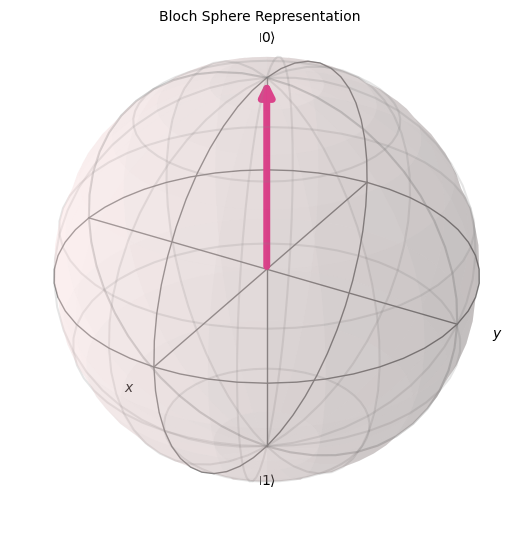

State vector: [0.70710678+0.j 0.70710678+0.j]


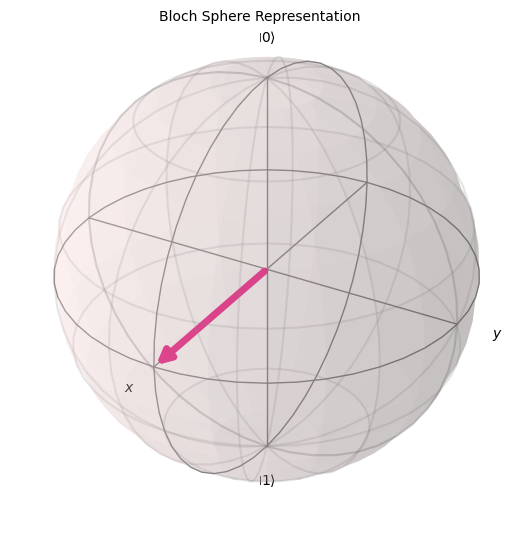

In [12]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def empty_circ():

    return qml.state()

@qml.qnode(dev)
def hadamard_circ():
    qml.Hadamard(wires=0)
    return qml.state()

plot_state_on_bloch(empty_circ)
plot_state_on_bloch(hadamard_circ)

## X,Y,Z Gates as Rotations on the Bloch Sphere

The X, Y, and Z gates we introduced earlier have a very elegant geometric interpretation when viewed through the Bloch sphere representation.

Each of these gates corresponds to a **rotation of the qubit state by an angle of $\pi$ (180°)** around one of the principal axes of the Bloch sphere:

- The **X gate** corresponds to a rotation by $\pi$ around the x-axis
- The **Y gate** corresponds to a rotation by $\pi$ around the y-axis
- The **Z gate** corresponds to a rotation by $\pi$ around the z-axis

This geometric picture explains why these gates “flip” or “phase-flip” states in the way we observed earlier.

To make this idea more general and flexible, we introduce the **rotation gates**:

- $R_x(\theta)$ — rotation around the x-axis
- $R_y(\theta)$ — rotation around the y-axis
- $R_z(\theta)$ — rotation around the z-axis

These gates are defined by the following matrix representations:

$$
R_x(\theta) =
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right) & -i\sin\left(\frac{\theta}{2}\right) \\
-i\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}
$$

$$
R_y(\theta) =
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right) \\
\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}
$$

$$
R_z(\theta) =
\begin{pmatrix}
e^{-i\theta/2} & 0 \\
0 & e^{i\theta/2}
\end{pmatrix}
$$

We can verify the connection with the basic X,Y,Z gates by setting $\theta = \pi$:

$$
R_x(\pi) = X, \qquad R_y(\pi) = Y, \qquad R_z(\pi) = Z.
$$

This shows that the mentioned basic gates are special cases of continuous rotations on the Bloch sphere.

Let us now explore how these rotation gates act on qubit states in practice.

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def make_rx_circuit(theta):
    dev = qml.device("default.qubit", wires=1)

    @qml.qnode(dev)
    def circuit():
        qml.RX(theta, wires=0)
        return qml.state()

    return circuit


def make_ry_circuit(theta):
    dev = qml.device("default.qubit", wires=1)

    @qml.qnode(dev)
    def circuit():
        qml.RY(theta, wires=0)
        return qml.state()

    return circuit


def make_rz_circuit(theta):
    dev = qml.device("default.qubit", wires=1)

    @qml.qnode(dev)
    def circuit():
        #qml.Hadamard(wires=0)
        qml.RZ(theta, wires=0)
        return qml.state()

    return circuit

In [14]:
def plot_rx(theta):
    clear_output(wait=True)

    circuit = make_rx_circuit(theta)
    state = circuit()
    bloch_vec = bloch_from_state(state)

    print("RX(θ) with θ =", theta)
    print("State:", state)

    fig = plot_bloch_vector(bloch_vec, title="RX rotation on Bloch sphere")
    display(fig)


widgets.interact(
    plot_rx,
    theta=widgets.FloatSlider(value=0.0, min=0, max=2*np.pi, step=0.05, description="θ")
)

interactive(children=(FloatSlider(value=0.0, description='θ', max=6.283185307179586, step=0.05), Output()), _d…

<function __main__.plot_rx(theta)>

In [15]:
def plot_ry(theta):
    clear_output(wait=True)

    circuit = make_ry_circuit(theta)
    state = circuit()
    bloch_vec = bloch_from_state(state)

    print("RY(θ) with θ =", theta)
    print("State:", state)

    fig = plot_bloch_vector(bloch_vec, title="RY rotation on Bloch sphere")
    display(fig)


widgets.interact(
    plot_ry,
    theta=widgets.FloatSlider(value=0.0, min=0, max=2*np.pi, step=0.01, description="θ")
)

interactive(children=(FloatSlider(value=0.0, description='θ', max=6.283185307179586, step=0.01), Output()), _d…

<function __main__.plot_ry(theta)>

In [16]:
def plot_rz(theta):
    clear_output(wait=True)

    circuit = make_rz_circuit(theta)
    state = circuit()
    bloch_vec = bloch_from_state(state)

    print("RZ(θ) with θ =", theta)
    print("State:", state)

    fig = plot_bloch_vector(bloch_vec, title="RZ rotation on Bloch sphere")
    display(fig)


widgets.interact(
    plot_rz,
    theta=widgets.FloatSlider(value=0.0, min=0, max=2*np.pi, step=0.01, description="θ")
)

interactive(children=(FloatSlider(value=0.0, description='θ', max=6.283185307179586, step=0.01), Output()), _d…

<function __main__.plot_rz(theta)>

## Quantum Circuits: Applying Multiple Gates

So far, we have been applying single quantum gates to a qubit. However, quantum computation becomes powerful when we start combining multiple gates into a **circuit**.

A **quantum circuit** is simply a sequence of quantum gates applied in a fixed order to one or more qubits.

Mathematically, this corresponds to applying unitary operations one after another:

$$
|\psi_{\text{out}}\rangle = U_n \cdots U_2 U_1 |\psi_{\text{in}}\rangle.
$$

The order matters: quantum gates generally **do not commute**, meaning that changing their order can change the final state.

### Circuit notation in PennyLane

In PennyLane, a quantum circuit is defined as a Python function decorated with `@qml.qnode`. Inside this function, we apply gates in order, just like writing steps in a recipe:

- each line corresponds to a quantum operation
- the function returns a measurement (for example the state or expectation values)

In the next section, we will build and visualize such circuits directly using PennyLane.

In [17]:
# --- Circuit 1: H then Z (HZ|0>)
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def circuit_HZ():
    qml.Hadamard(wires=0)
    qml.Z(wires=0)
    return qml.state()


# --- Circuit 2: Z then H (ZH|0>)
@qml.qnode(dev)
def circuit_ZH():
    qml.Z(wires=0)
    qml.Hadamard(wires=0)
    return qml.state()

HZ|0> state: [ 0.70710678+0.j -0.70710678+0.j]
ZH|0> state: [0.70710678+0.j 0.70710678+0.j]

--- Circuit diagrams (text) ---

HZ circuit:
0: ──H──Z─┤  State

ZH circuit:
0: ──Z──H─┤  State

--- Circuit diagrams (matplotlib) ---


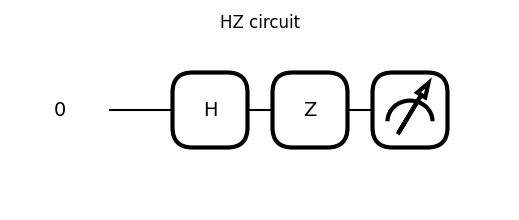

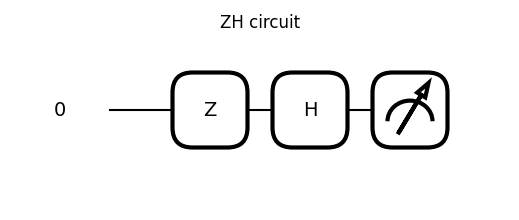


Bloch vector HZ|0>: [-1.  0.  0.]
Bloch vector ZH|0>: [1. 0. 0.]


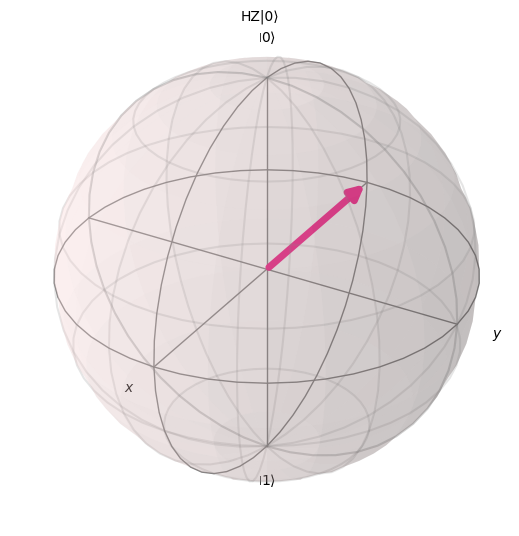

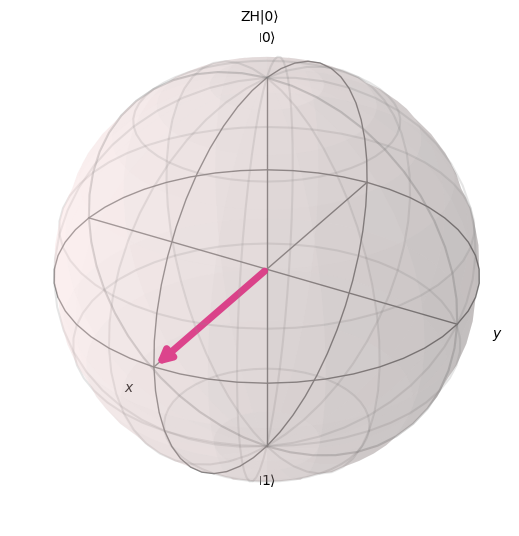

In [18]:
# --- Run circuits ---
state_HZ = circuit_HZ()
state_ZH = circuit_ZH()

print("HZ|0> state:", state_HZ)
print("ZH|0> state:", state_ZH)

# =========================
# Circuit drawings (TEXT)
# =========================

print("\n--- Circuit diagrams (text) ---\n")
print("HZ circuit:")
print(qml.draw(circuit_HZ)())
print("\nZH circuit:")
print(qml.draw(circuit_ZH)())

# =========================
# Circuit drawings (MPL)
# =========================

print("\n--- Circuit diagrams (matplotlib) ---")

fig_hz, ax_hz = qml.draw_mpl(circuit_HZ)()
fig_hz.suptitle("HZ circuit")
plt.close(fig_hz)
display(fig_hz)

fig_zh, ax_zh = qml.draw_mpl(circuit_ZH)()
fig_zh.suptitle("ZH circuit")
plt.close(fig_zh)
display(fig_zh)

# --- Bloch vectors ---
bloch_HZ = bloch_from_state(state_HZ)
bloch_ZH = bloch_from_state(state_ZH)

print("\nBloch vector HZ|0>:", bloch_HZ)
print("Bloch vector ZH|0>:", bloch_ZH)


# --- Plot Bloch spheres ---
fig1 = plot_bloch_vector(bloch_HZ, title="HZ|0⟩")
fig2 = plot_bloch_vector(bloch_ZH, title="ZH|0⟩")

display(fig1)
display(fig2)

## Measurement in a Single-Qubit System

Until now, we have treated a qubit as a mathematical object that evolves deterministically under quantum gates. However, when we **measure** a qubit, something fundamentally different happens.

Measurement is the bridge between the quantum world and classical information.

---

### The key idea

A single-qubit state can be written as:

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle,
$$

where $\alpha$ and $\beta$ are complex amplitudes satisfying:

$$
|\alpha|^2 + |\beta|^2 = 1.
$$

When we measure the qubit in the computational basis:

- We obtain **0** with probability $|\alpha|^2$
- We obtain **1** with probability $|\beta|^2$

---

### The “collapse” of the state

After measurement, the quantum state is no longer a superposition. Instead, it **collapses** to the observed outcome:

- If the result is 0:
  $$
  |\psi\rangle \rightarrow |0\rangle
  $$

- If the result is 1:
  $$
  |\psi\rangle \rightarrow |1\rangle
  $$

This means measurement is **not reversible** and fundamentally changes the state.

---

### Example intuition

Consider the Hadamard state:

$$
|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}.
$$

If we measure this state:

- Probability of 0: $1/2$
- Probability of 1: $1/2$

Even though the system is in a *definite quantum state before measurement*, the result we observe is inherently probabilistic.

---

### What changes compared to classical computation?

In classical computing:

- A bit is always 0 or 1
- We can read it without changing it

In quantum computing:

- A qubit can be in a superposition
- Measurement forces a random outcome according to quantum probabilities
- The act of observing changes the state itself

---

### Next step

We will now see how to implement measurement in PennyLane and simulate repeated shots to observe probability distributions in practice.

In [19]:
dev_single = qml.device("default.qubit", wires=1, shots=1)
dev_multi = qml.device("default.qubit", wires=1, shots=1000)

# =========================
# Circuit: Hadamard state
# =========================
@qml.qnode(dev_single)
def hadamard_measure_single_shot():
    qml.Hadamard(wires=0)
    return qml.sample(qml.Z(0))  # measurement in computational basis

@qml.qnode(dev_multi)
def hadamard_measure():
    qml.Hadamard(wires=0)
    return qml.sample(qml.Z(0))  # measurement in computational basis


# --- Run Hadamard experiment ---
print(hadamard_measure_single_shot())

[-1.]


/Users/amer/Work/Projects/hdcrs-school-2026/.venv/lib/python3.11/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [20]:
results_h = hadamard_measure()

# convert {-1, +1} to {0, 1}
counts_h = {
    "0": np.sum(results_h == 1),
    "1": np.sum(results_h == -1),
}

print("Hadamard measurement results (1000 shots):")
print("Counts:", counts_h)
print("Probabilities:", {k: v/1000 for k, v in counts_h.items()})

Hadamard measurement results (1000 shots):
Counts: {'0': np.int64(513), '1': np.int64(487)}
Probabilities: {'0': np.float64(0.513), '1': np.float64(0.487)}


In [21]:
# =========================
# Circuit: RX rotation example
# =========================
dev = qml.device("default.qubit", wires=1)
@qml.qnode(dev)
def rx_state(theta):
    qml.RX(theta, wires=0)
    return qml.state()

@qml.qnode(dev_multi)
def rx_measure(theta):
    qml.RX(theta, wires=0)
    return qml.sample(qml.PauliZ(0))

# --- Run RX example ---
theta = np.pi / 3
results_rx = rx_measure(theta)
print("State simulation: ",rx_state(theta))
print("State simulation probabilities: ",rx_state(theta)*np.conj(rx_state(theta)))

counts_rx = {
    "0": np.sum(results_rx == 1),
    "1": np.sum(results_rx == -1),
}

print(f"\nRX({theta:.2f}) measurement results (1000 shots):")
print("Counts:", counts_rx)
print("Probabilities:", {k: v/1000 for k, v in counts_rx.items()})

State simulation:  [0.8660254+0.j  0.       -0.5j]
State simulation probabilities:  [0.75+0.j 0.25+0.j]

RX(1.05) measurement results (1000 shots):
Counts: {'0': np.int64(762), '1': np.int64(238)}
Probabilities: {'0': np.float64(0.762), '1': np.float64(0.238)}


## Multi-Qubit Systems

So far, we have worked with single qubits. To understand more powerful quantum computations, we now move to **multi-qubit systems**, where multiple qubits are combined into a single quantum state.

---

## 1. Exponential Growth of the State Space

A single qubit is described by:

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle.
$$

A system of two qubits is described by:

$$
|\psi\rangle =
\alpha_{00}|00\rangle +
\alpha_{01}|01\rangle +
\alpha_{10}|10\rangle +
\alpha_{11}|11\rangle.
$$

Each additional qubit doubles the number of amplitudes required to describe the system.

In general, for $n$ qubits, the state is described by $2^n$ complex amplitudes.

This exponential scaling is one of the key differences between classical and quantum systems.

---

## 2. Tensor Product Structure

Multi-qubit states are constructed using the **tensor product** of individual qubit states.

For example, if we have two independent qubits:

$$
|0\rangle \otimes |1\rangle = |01\rangle.
$$

More generally, if:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle,
\qquad
|\phi\rangle = \gamma|0\rangle + \delta|1\rangle,
$$

then the two-qubit state is:

$$
|\psi\rangle \otimes |\phi\rangle.
$$

This construction combines single-qubit systems into a joint quantum system.

---

## 3. Product States vs General Two-Qubit States

Not all multi-qubit states can be written as a simple product of individual qubit states.

### Product states

A state is a **product (separable) state** if it can be written as:

$$
|\psi\rangle = |\psi_1\rangle \otimes |\psi_2\rangle.
$$

In this case, each qubit has its own independent description.

---

### General states

However, a general two-qubit state has the form:

$$
|\psi\rangle =
\alpha_{00}|00\rangle +
\alpha_{01}|01\rangle +
\alpha_{10}|10\rangle +
\alpha_{11}|11\rangle,
$$

and may **not be decomposable** into a product of two single-qubit states.

This distinction will become crucial when we introduce **entanglement**, where the behavior of one qubit cannot be described independently of the other.

## The CNOT Gate (Controlled-NOT)

To work with multi-qubit systems, we need gates that act on more than one qubit. The most important example is the **CNOT gate** (Controlled-NOT).

The CNOT gate acts on two qubits:

- The first qubit is called the **control**
- The second qubit is called the **target**

Its action is simple:

- If the control qubit is $|0\rangle$, nothing happens
- If the control qubit is $|1\rangle$, the target qubit is flipped (NOT applied)

In computational basis notation:

$$
|00\rangle \rightarrow |00\rangle
$$

$$
|01\rangle \rightarrow |01\rangle
$$

$$
|10\rangle \rightarrow |11\rangle
$$

$$
|11\rangle \rightarrow |10\rangle
$$

In matrix form, it can be written as:

$$
\mathrm{CNOT} =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}.
$$

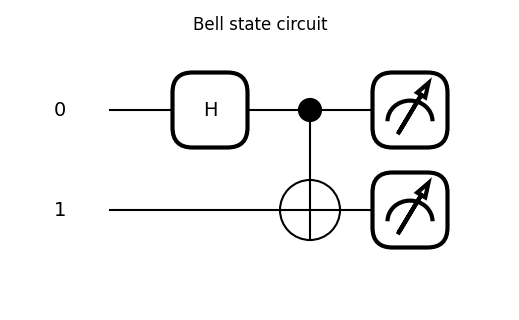

Bell state vector:
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


In [22]:
dev = qml.device("default.qubit", wires=2) # Two wires = two qubits!

@qml.qnode(dev)
def bell_state():
    # Start in |00>
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.state()

fig_B, ax_B = qml.draw_mpl(bell_state)()
fig_B.suptitle("Bell state circuit")
plt.close(fig_B)
display(fig_B)

state = bell_state()
print("Bell state vector:")
print(state)

## The Bell State (Maximally Entangled State)

By combining a Hadamard gate with a CNOT gate, we can create one of the most important states in quantum computing: the **Bell state**.

Starting from the initial state:

$$
|00\rangle,
$$

we apply:

1. A Hadamard gate on the first qubit:
$$
|00\rangle \rightarrow \frac{|00\rangle + |10\rangle}{\sqrt{2}}
$$

2. A CNOT gate (control = first qubit, target = second qubit):
$$
\frac{|00\rangle + |10\rangle}{\sqrt{2}}
\rightarrow
\frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

The resulting state is:

$$
|\Phi^+\rangle =
\frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

This is a **maximally entangled state**, meaning that the two qubits are no longer independent.

A measurement of one qubit immediately determines the outcome of the other, even though each individual outcome is still random.

In [23]:
dev_multi = qml.device("default.qubit", wires=2, shots=1000)


# =========================
# Bell state circuit
# =========================
@qml.qnode(dev_multi)
def bell_measure():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.sample()


# Run experiment
samples = bell_measure()

# Convert samples to bitstrings
bitstrings = ["".join(str(b) for b in s) for s in samples]

# Count occurrences
unique, counts = np.unique(bitstrings, return_counts=True)
freqs = dict(zip(unique, counts))

print("Bell state measurement results (1000 shots):\n")
print("Counts:")
for k, v in freqs.items():
    print(f"{k}: {v}")

print("\nExpected structure:")
print("Only |00> and |11> should appear (no |01>, |10>)")

Bell state measurement results (1000 shots):

Counts:
00: 493
11: 507

Expected structure:
Only |00> and |11> should appear (no |01>, |10>)


/Users/amer/Work/Projects/hdcrs-school-2026/.venv/lib/python3.11/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [24]:
def reduced_purity(state):
    """Purity of reduced density matrix of qubit 0."""
    
    # density matrix
    rho = np.outer(state, np.conj(state))
    
    # reshape into 2-qubit tensor: (i,j,k,l)
    rho = rho.reshape(2, 2, 2, 2)

    # trace out qubit 1 → keep qubit 0
    rho_A = np.trace(rho, axis1=1, axis2=3)

    # purity Tr(rho^2)
    purity = np.real(np.trace(rho_A @ rho_A))
    
    return purity

In [25]:
dev = qml.device("default.qubit", wires=2)
dev_multi = qml.device("default.qubit", wires=2, shots=1000)

@qml.qnode(dev)
def bell_state(theta):
    qml.Hadamard(wires=0)
    qml.RY(theta, wires=1)
    qml.CNOT(wires=[0, 1])
    return qml.state()


@qml.qnode(dev_multi)
def bell_samples(theta):
    qml.Hadamard(wires=0)
    qml.RY(theta, wires=1)
    qml.CNOT(wires=[0, 1])
    return qml.sample()

In [26]:
out = widgets.Output()

def run(theta):
    state = bell_state(theta)
    samples = bell_samples(theta)

    purity = reduced_purity(state)

    bitstrings = ["".join(str(b) for b in s) for s in samples]
    unique, counts = np.unique(bitstrings, return_counts=True)
    freqs = dict(zip(unique, counts))

    with out:
        out.clear_output(wait=True)

        print(f"θ = {theta:.2f}")
        print(f"Purity (reduced state): {purity:.4f}")
        print("Entanglement:", "HIGH" if purity < 0.9 else "LOW")

        print("\nMeasurement counts:")
        for k in sorted(freqs.keys()):
            print(f"{k}: {freqs[k]}")

        plt.figure()
        plt.bar(freqs.keys(), freqs.values())
        plt.title("Bell-state measurement statistics")
        plt.xlabel("bitstring")
        plt.ylabel("counts")
        plt.show()


slider = widgets.FloatSlider(
    value=0.0,
    min=0.0,
    max=np.pi,
    step=0.01,
    description="θ"
)

ui = widgets.VBox([slider, out])
display(ui)

widgets.interactive_output(run, {"theta": slider})

Output()

## Entanglement: A New Kind of Correlation

Entanglement is one of the most important and least classical features of quantum mechanics. It describes a situation where multiple qubits behave as a single, inseparable system.

---

### From independent systems to joint systems

In classical intuition, if we have two systems, we expect that:

- each system has its own state
- the total state is just a combination of the two
- we can describe each part independently

In quantum mechanics, this is sometimes true — but not always.

A two-qubit system can be written as:

- a **product state** (independent qubits), or
- a **general state** where such a separation is impossible

---

### What makes entanglement special?

In an entangled state, the full system is well-defined, but the individual parts are not.

This leads to a surprising situation:

> Each qubit alone can look completely random, but together they show strong structure.

---

### A simple intuition

Consider the Bell state:

$$
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

If we measure only one qubit:

- we obtain 0 or 1 with equal probability

So locally, the system looks random.

But if we measure both qubits:

- we always get the same result: 00 or 11

This means:

- the outcomes are **perfectly correlated**
- but neither qubit “decides” the result on its own

---

### A different kind of correlation

Classical correlations come from shared hidden information.

Quantum entanglement is different:

- there is no independent description of each subsystem
- the correlation is built into the structure of the state itself

---

### Key takeaway

Entanglement does not mean “strong randomness” or “strong connection” in a classical sense.

It means:

> The state of the whole system cannot be reduced to states of its parts.

---

### Why it matters

Entanglement is a key resource in quantum computing. It enables:

- quantum teleportation
- quantum error correction
- quantum speedups in certain algorithms

## A Simple Quantum Algorithm: Interference as Computation

We now look at a very simple quantum "algorithm" that demonstrates one of the central ideas of quantum computing: using **interference** to extract information.

The key idea is:

> We encode information into phases, and use interference to reveal that information through measurement.

This mechanism lies at the heart of many quantum algorithms.

---

### Functions and quantum oracles

Suppose we are given a classical function

$$
f : \{0,1\} \rightarrow \{0,1\}.
$$

For a single input bit, there are four possible functions:

| Input | Constant 0 | Constant 1 | Identity | Negation |
|---------|---------|---------|---------|---------|
| 0 | 0 | 1 | 0 | 1 |
| 1 | 0 | 1 | 1 | 0 |

A quantum computer cannot directly apply a classical function. Instead, the function must be represented by a **quantum oracle**, which is a unitary operation acting on quantum states.

In this tutorial, we use a particularly simple type of oracle called a **phase oracle**. Its action is

$$
|x\rangle \rightarrow (-1)^{f(x)} |x\rangle.
$$

Notice that the basis state itself is unchanged. The only effect is a possible sign change.

---

### Two simple examples

If the function is

$$
f(x)=0,
$$

then

$$
(-1)^{f(x)} = +1,
$$

and the oracle does nothing.

If the function is

$$
f(x)=x,
$$

then

$$
|0\rangle \rightarrow |0\rangle,
$$

$$
|1\rangle \rightarrow -|1\rangle.
$$

This is exactly the action of the Pauli-Z gate:

$$
Z=
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}.
$$

Therefore, in our implementation:

- no gate corresponds to the constant function $f(x)=0$,
- a Z gate corresponds to the function $f(x)=x$.

---

### The algorithm

We will build the following circuit:

1. Prepare a superposition using a Hadamard gate.
2. Apply a phase oracle encoding the hidden function.
3. Apply another Hadamard gate.
4. Measure the qubit.

The remarkable feature is that the final measurement reveals a property of the hidden function through interference.

In [27]:
dev = qml.device("default.qubit", wires=1)

# hidden function (two possibilities)
# f0: no phase flip
# f1: phase flip

def circuit(flip=False):
    @qml.qnode(dev)
    def qc():
        qml.Hadamard(wires=0)
        # encode function as phase
        if flip:
            qml.Z(wires=0)
        qml.Hadamard(wires=0)
        return qml.sample(qml.PauliZ(0))
    return qc

In [28]:
f0 = circuit(flip=False)
f1 = circuit(flip=True)

shots = 1000

dev = qml.device("default.qubit", wires=1, shots=shots)


@qml.qnode(dev)
def run_f0():
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=0)
    return qml.sample(qml.Z(0))


@qml.qnode(dev)
def run_f1():
    qml.Hadamard(wires=0)
    qml.Z(wires=0)
    qml.Hadamard(wires=0)
    return qml.sample(qml.Z(0))


res0 = run_f0()
res1 = run_f1()

print("Function f0 (no phase flip):")
print("mean outcome:", np.mean(res0))

print("\nFunction f1 (phase flip):")
print("mean outcome:", np.mean(res1))

Function f0 (no phase flip):
mean outcome: 1.0

Function f1 (phase flip):
mean outcome: -1.0


## A Simple Quantum Algorithm (n-Qubit Version): Deutsch–Jozsa

We now generalize our previous interference-based idea to multiple qubits.

The goal is to determine a property of a function using quantum interference.

---

### The problem setup

We are given a black-box function:

$$
f : \{0,1\}^n \rightarrow \{0,1\}
$$

We assume that the function is either:

- **constant**: returns the same value for all inputs  
- **balanced**: returns 0 for half of the inputs and 1 for the other half

---

### Classical intuition

A classical algorithm may need to evaluate the function many times to decide which case we are in.

---

### Quantum idea

We:

1. Prepare a uniform superposition over all inputs
2. Encode the function into quantum phases
3. Use interference to amplify global structure
4. Measure all qubits at once

---

### Key result

After the circuit:

- If the function is constant → we always measure:
  $$
  |00...0\rangle
  $$

- If the function is balanced → we will never measure all zeros

---

### Why its interesting

A single quantum evaluation of the function reveals a **global property** of the function, not individual values.

This is a simple example of how quantum interference can outperform classical reasoning.

In [29]:
# number of qubits
n = 4

dev = qml.device("default.qubit", wires=n, shots=1000)


# =========================
# Oracle definitions
# =========================

def constant_oracle():
    # f(x)=0 (do nothing)
    pass


def balanced_oracle():
    # f(x_1 x_2....) = x_1
    qml.Z(wires=0)


# =========================
# Deutsch–Jozsa circuit
# =========================

def dj_circuit(oracle):

    @qml.qnode(dev)
    def circuit():
        # prepare uniform superposition
        for i in range(n):
            qml.Hadamard(wires=i)

        # oracle encoding
        oracle()

        # interference step
        for i in range(n):
            qml.Hadamard(wires=i)

        return qml.sample()

    return circuit

In [30]:
const_circ = dj_circuit(constant_oracle)
bal_circ = dj_circuit(balanced_oracle)


res_const = const_circ()
res_bal = bal_circ()


def classify(samples):
    bitstrings = ["".join(str(b) for b in s) for s in samples]
    unique = set(bitstrings)
    return unique


print("Constant oracle outcomes (unique results):")
print(classify(res_const))

print("\nBalanced oracle outcomes (unique results):")
print(classify(res_bal))

Constant oracle outcomes (unique results):
{'0000'}

Balanced oracle outcomes (unique results):
{'1000'}


# Actual Device Computation

In [31]:
# If not installed yet:
# pip install qiskit qiskit-aer qiskit-ibm-runtime pennylane-qiskit

import numpy as np
import pennylane as qml
from qiskit_ibm_runtime import QiskitRuntimeService
from collections import Counter

n = 4

In [32]:
# First-time setup (run once interactively):
#QiskitRuntimeService.save_account(channel="ibm_cloud", token="E")

service = QiskitRuntimeService()

# pick least busy backend
backend = service.least_busy(operational=True, simulator=False)
print("Using backend:", backend.name)

qiskit_runtime_service.__init__:WARNING:2026-06-10 08:57:00,138: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-10 08:57:00,726: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-10 08:57:04,744: Using instance: open-instance, plan: open


Using backend: ibm_kingston


In [33]:
shots = 1024

dev = qml.device(
    "qiskit.remote",
    wires=n,
    backend=backend,
    shots=shots
)

/Users/amer/Work/Projects/hdcrs-school-2026/.venv/lib/python3.11/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [34]:
def constant_oracle():
    pass


def balanced_oracle():
    # simple balanced oracle: Z on first qubit only
    qml.Z(wires=0)


@qml.qnode(dev)
def dj_circuit(oracle):

    # Hadamard layer
    for i in range(n):
        qml.Hadamard(wires=i)

    # oracle
    oracle()

    # interference layer
    for i in range(n):
        qml.Hadamard(wires=i)

    return qml.sample()

In [35]:
def bitstring_counts(samples):

    bitstrings = ["".join(str(b) for b in s) for s in samples]

    counts = Counter(bitstrings)

    # normalize to probabilities

    total = sum(counts.values())

    probs = {k: v / total for k, v in counts.items()}

    return counts, probs

In [36]:
res_const = dj_circuit(constant_oracle)

res_bal = dj_circuit(balanced_oracle)

counts_const, probs_const = bitstring_counts(res_const)

counts_bal, probs_bal = bitstring_counts(res_bal)

print("\n=== Constant oracle (counts) ===")

for k, v in sorted(counts_const.items()):

    print(f"{k}: {v}")

print("\n=== Constant oracle (probabilities) ===")

for k, v in sorted(probs_const.items()):

    print(f"{k}: {v:.3f}")

print("\n\n=== Balanced oracle (counts) ===")

for k, v in sorted(counts_bal.items()):

    print(f"{k}: {v}")

print("\n=== Balanced oracle (probabilities) ===")

for k, v in sorted(probs_bal.items()):

    print(f"{k}: {v:.3f}")


=== Constant oracle (counts) ===
0000: 1017
0001: 2
0010: 3
0100: 2

=== Constant oracle (probabilities) ===
0000: 0.993
0001: 0.002
0010: 0.003
0100: 0.002


=== Balanced oracle (counts) ===
0000: 12
1000: 1005
1001: 3
1010: 3
1100: 1

=== Balanced oracle (probabilities) ===
0000: 0.012
1000: 0.981
1001: 0.003
1010: 0.003
1100: 0.001


## Quantum Simulators in PennyLane

So far, we have been running quantum circuits on a simulator. A simulator is a classical program that mimics the behavior of a quantum computer.

However, not all simulators are the same. In PennyLane, different backends provide different levels of speed, accuracy, and realism.

---

## 1. Ideal simulators

These simulators compute the exact quantum state without any physical imperfections.

### Examples:
- `default.qubit`
- `lightning.qubit`

### Characteristics:
- No noise (perfect quantum evolution)
- Deterministic results (for statevector simulations)
- Very useful for learning and algorithm development

The difference between them is mainly performance:
- `default.qubit` is simple and easy to use
- `lightning.qubit` is much faster (implemented in C++)

---

## 2. Real quantum hardware

In addition to simulators, circuits can be executed on real quantum devices (e.g., IBM Quantum processors).

### Characteristics:
- Physical qubits instead of simulated ones
- Always noisy
- Limited number of qubits and operations
- Queue time required for execution

---

## 3. Why this matters

When studying quantum algorithms, it is important to distinguish between:

- **ideal behavior** (theory and algorithm design)
- **noisy behavior** (realistic implementation)
- **hardware behavior** (physical execution)

Understanding all three is essential for moving from quantum theory to real quantum computing applications.

In [37]:
# -------------------------
# Ideal simulator (slow but simple)
# -------------------------
dev_default = qml.device("default.qubit", wires=2, shots=1000)


@qml.qnode(dev_default)
def circuit_default():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1])
    return qml.sample()


# -------------------------
# Fast simulator (recommended for larger circuits)
# -------------------------
#dev_lightning = qml.device("lightning.qubit", wires=1)


#@qml.qnode(dev_lightning)
#def circuit_lightning():
#    qml.Hadamard(wires=0)
#    return qml.state()


# -------------------------
# Noisy simulation (Qiskit-style)
# -------------------------
dev_noisy = qml.device("default.mixed", wires=2, shots=1000)


@qml.qnode(dev_noisy)

def circuit_noisy():
    qml.Hadamard(wires=0)
    qml.DepolarizingChannel(0.05, wires=0)
    qml.CNOT(wires=[0, 1])
    qml.DepolarizingChannel(0.05, wires=0)
    qml.DepolarizingChannel(0.05, wires=1)
    return qml.sample()


# -------------------------
# Run all three
# -------------------------
print("=== Ideal simulation (default.qubit) ===")
samples_noiseless = circuit_default()

bitstrings_noiseless = ["".join(str(b) for b in s) for s in samples_noiseless]
unique_noiseless, counts_noiseless = np.unique(bitstrings_noiseless, return_counts=True)
freqs = dict(zip(unique_noiseless, counts_noiseless))

print("\nNoiseless measurement results:")
print(counts_noiseless)

print("\n=== Noisy simulation (default.mixed) ===")
samples_noisy = circuit_noisy()

bitstrings_noisy = ["".join(str(b) for b in s) for s in samples_noisy]
unique_noisy, counts_noisy = np.unique(bitstrings_noisy, return_counts=True)
freqs_noisy = dict(zip(unique_noisy, counts_noisy))

print("\nNoisy measurement results:")
print(counts_noisy)

=== Ideal simulation (default.qubit) ===

Noiseless measurement results:
[509 491]

=== Noisy simulation (default.mixed) ===

Noisy measurement results:
[464  29  34 473]
